<a href="https://colab.research.google.com/github/JoyNgaru/Data-Analysis/blob/main/kenyan_food_security_dataset_cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data from Google Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once your Google Drive is mounted, you can load your data. For example, if you have a CSV file, you can use pandas:

```python
import pandas as pd

# Replace 'path/to/your/file.csv' with the actual path to your file in Google Drive
df = pd.read_csv('/content/drive/MyDrive/path/to/your/file.csv')

# Display the first 5 rows of the DataFrame
display(df.head())
```

Remember to adjust the file path to match the location of your data within your Google Drive.

You can modify the `drive_path` variable in the code above to explore specific subfolders within your Google Drive, for example:

```python
drive_path = '/content/drive/MyDrive/my_folder/my_subfolder'
```

Once you find your file, remember to update the `pd.read_csv` path accordingly.

In [11]:
import pandas as pd

# Using the correct filename 'ipc dataset' located in the 'Colab Notebooks' folder
ipc_file_path = '/content/drive/MyDrive/Colab Notebooks/ipc dataset'

try:
    df_ipc = pd.read_csv(ipc_file_path)
    print(f"Successfully loaded data from '{ipc_file_path}'")
    display(df_ipc.head())
except FileNotFoundError:
    print(f"Error: The file '{ipc_file_path}' was not found. Please verify the file name and path.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}. If this is not a CSV file, please specify its format (e.g., Excel, plain text).")

An error occurred while loading the file: [Errno 21] Is a directory: '/content/drive/MyDrive/Colab Notebooks/ipc dataset'. If this is not a CSV file, please specify its format (e.g., Excel, plain text).


In [12]:
import os

# Path to the 'ipc dataset' folder
ipc_dataset_folder_path = '/content/drive/MyDrive/Colab Notebooks/ipc dataset'

print(f"Contents of '{ipc_dataset_folder_path}':")
if os.path.exists(ipc_dataset_folder_path):
    for item in os.listdir(ipc_dataset_folder_path):
        print(item)
else:
    print(f"The folder '{ipc_dataset_folder_path}' does not exist. Please ensure the path is correct.")


Contents of '/content/drive/MyDrive/Colab Notebooks/ipc dataset':
ipc_rainfall_ndvi_master_dataset.csv
clustering.py


In [13]:
import pandas as pd

# Path to the CSV file identified within the 'ipc dataset' folder
csv_file_path = '/content/drive/MyDrive/Colab Notebooks/ipc dataset/ipc_rainfall_ndvi_master_dataset.csv'

try:
    df_ipc_dataset = pd.read_csv(csv_file_path)
    print(f"Successfully loaded data from '{csv_file_path}'")
    display(df_ipc_dataset.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please verify the file name and path.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Successfully loaded data from '/content/drive/MyDrive/Colab Notebooks/ipc dataset/ipc_rainfall_ndvi_master_dataset.csv'


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg,date,mean_ndvi,ndvi_1_month_mean,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,172.723779,47.813818,28.787296,2019-06-01,0.645498,0.645498,0.469621,0.424800,0.078739
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,156.388124,41.315655,26.064687,2019-06-01,0.710059,0.710059,0.715939,0.708263,-0.026823
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,66.812339,18.395066,11.135390,2019-06-01,0.211246,0.211246,0.247841,0.247458,-0.047864
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,40.062429,8.863886,6.677072,2019-06-01,0.207090,0.207090,0.223339,0.220767,-0.042075
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,88.344720,20.905620,14.724120,2019-06-01,0.379489,0.379489,0.389526,0.366431,-0.030230


## Clustering Analysis

Now that the data is loaded, let's proceed with clustering using K-Means and DBSCAN. This will involve:

1.  **Selecting relevant features** for clustering.
2.  **Handling missing values** to ensure data quality.
3.  **Scaling features** to prevent features with larger values from dominating the clustering process.
4.  **Running K-Means clustering** and evaluating its performance using the Silhouette Score.
5.  **Running DBSCAN clustering** and inspecting its results.
6.  **Visualizing the clusters** for both algorithms to understand their distribution.

K-Means Silhouette Score: 0.2676253380627876
    county  dbscan_cluster
0  Baringo            -1.0
1     Embu            -1.0
2  Garissa             0.0
3   Isiolo             0.0
4  Kajiado             1.0


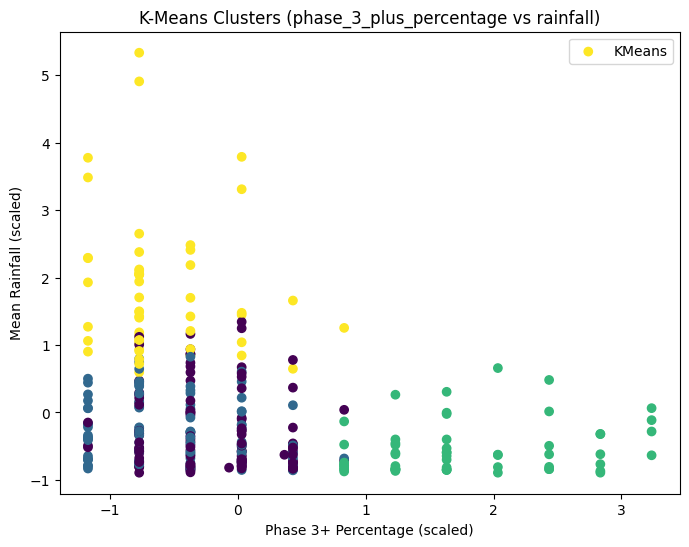

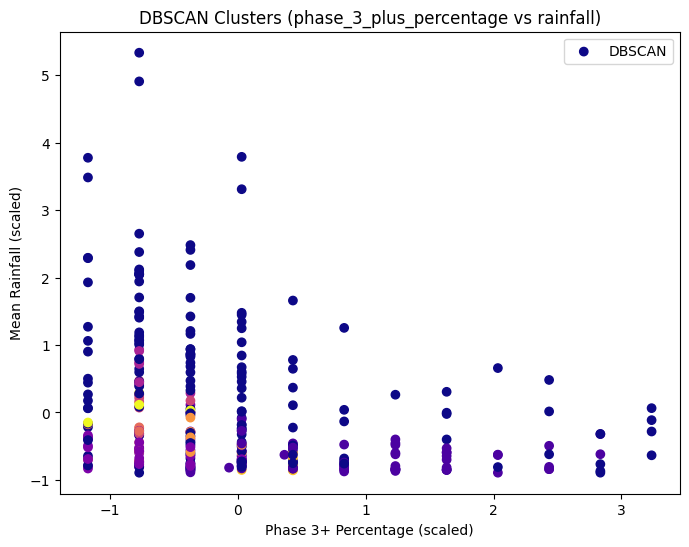

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Use the loaded DataFrame
df = df_ipc_dataset.copy() # Create a copy to avoid modifying the original loaded DataFrame

# 2. Select relevant features
features = ['phase_3_plus_percentage',
            'mean_rainfall_mm',
            'mean_ndvi',
            'ndvi_anomaly']
X = df[features]

# 3. Handle missing values
X = X.dropna()

# Keep track of original indices after dropping NaNs to map clusters back
df_original_indices = X.index

# 4. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# K-MEANS CLUSTERING
# -----------------------------
# 5. Run K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10) # Added n_init for KMeans
df.loc[df_original_indices, 'kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# 6. Evaluate K-Means
silhouette_kmeans = silhouette_score(X_scaled, df.loc[df_original_indices, 'kmeans_cluster'])
print("K-Means Silhouette Score:", silhouette_kmeans)

# -----------------------------
# DBSCAN CLUSTERING
# -----------------------------
# 7. Run DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df.loc[df_original_indices, 'dbscan_cluster'] = dbscan.fit_predict(X_scaled)

# 8. Inspect DBSCAN results
print(df[['county','dbscan_cluster']].head())

# -----------------------------
# OPTIONAL: Visualization
# -----------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=df.loc[df_original_indices, 'kmeans_cluster'], cmap='viridis', label='KMeans')
plt.title("K-Means Clusters (phase_3_plus_percentage vs rainfall)")
plt.xlabel("Phase 3+ Percentage (scaled)")
plt.ylabel("Mean Rainfall (scaled)")
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1],
            c=df.loc[df_original_indices, 'dbscan_cluster'], cmap='plasma', label='DBSCAN')
plt.title("DBSCAN Clusters (phase_3_plus_percentage vs rainfall)")
plt.xlabel("Phase 3+ Percentage (scaled)")
plt.ylabel("Mean Rainfall (scaled)")
plt.legend()
plt.show()